# Gurobi scaling analysis

In this notebook we solve the solomon instances timing each run.
We compare some Solomon families to see how the customer layout and the time-window change

## Imports

In [7]:
import sys
import os

root = os.path.dirname(os.getcwd())
sys.path.append(root)

import time
import matplotlib.pyplot as plt

from cvrptw.parser import parse_solomon
from cvrptw.model import Instance
from cvrptw.solvers.gurobi_solver import solve

## A sub-instance of the first n customers


In [ ]:
def n_customers(instance, n):
    return Instance(instance.name, instance.vehicle_capacity, instance.nodes[:n + 1], instance.num_vehicles)

## Run the experiment

One representative instance per Solomon family:
- **c1 / c2**: clustered locations (tight / wide windows)
- **r1 / r2**: random locations (tight / wide windows)
- **rc1 / rc2**: mixed locations (tight / wide windows)


In [ ]:
families = ['c101', 'c201', 'r101', 'r201', 'rc101', 'rc201']
sizes = list(range(10, 81, 10)) 

results = {}
for name in families:
    data = parse_solomon(f'../data/solomon/{name}.txt')
    xs = []
    ys = []
    for size in sizes:
        sub = n_customers(data, size)
        start = time.perf_counter()
        solve(sub)
        elapsed = time.perf_counter() - start
        xs.append(size)
        ys.append(elapsed)
        print(f'{name:6s}  n={size:3d}  time={elapsed:9.2f}s')
    results[name] = (xs, ys)

c101    n= 10  time=     0.18s
c101    n= 20  time=     0.16s
c101    n= 30  time=     0.47s
c101    n= 40  time=     0.97s
c101    n= 50  time=     1.55s
c101    n= 60  time=     1.54s
c101    n= 70  time=     2.25s
c101    n= 80  time=     3.34s
c201    n= 10  time=     0.09s
c201    n= 20  time=     0.24s
c201    n= 30  time=     0.69s
c201    n= 40  time=     0.90s
c201    n= 50  time=     1.10s
c201    n= 60  time=     3.24s
c201    n= 70  time=     2.38s
c201    n= 80  time=     3.64s
r101    n= 10  time=     0.09s
r101    n= 20  time=     0.21s
r101    n= 30  time=     0.63s
r101    n= 40  time=     0.72s
r101    n= 50  time=     1.16s
r101    n= 60  time=     1.71s
r101    n= 70  time=     3.25s
r101    n= 80  time=     2.78s
r201    n= 10  time=     0.07s
r201    n= 20  time=     0.37s
r201    n= 30  time=     1.00s
r201    n= 40  time=     1.76s
r201    n= 50  time=     3.64s
r201    n= 60  time=     7.01s
r201    n= 70  time=    15.19s
r201    n= 80  time=    16.05s
rc101   

## Plot the evolution

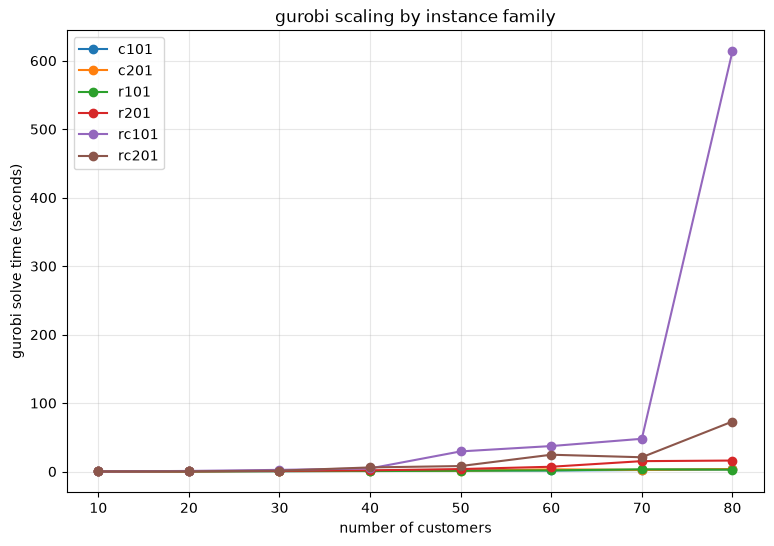

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, (xs, ys) in results.items():
    ax.plot(xs, ys, marker='o', label=name)

ax.set_xlabel('number of customers')
ax.set_ylabel('gurobi solve time (seconds)')
ax.set_title('gurobi scaling by instance family')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()